In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_curve,roc_auc_score

In [7]:
np.random.seed(42)
n = 300
data = pd.DataFrame({
    "age":np.random.randint(18,60,n),
    "salary":np.random.randint(20000,100000,n),
    "balance":np.random.randint(0,200000,n)
})
data["churn"] = (
    (data["balance"] > 100000).astype(int) |
    (data["salary"] > 40000).astype(int)
).astype(int)
data.head()


,age,salary,balance,churn
0,56,59790,52528,1
1,46,25600,38413,0
2,32,60764,52638,1
3,25,94543,183808,1
4,38,65714,110133,1


In [8]:
print(data.shape)
print(data.info())
print(data.describe())
print(data['churn'].value_counts)

(300, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   age      300 non-null    int64
 1   salary   300 non-null    int64
 2   balance  300 non-null    int64
 3   churn    300 non-null    int64
dtypes: int64(4)
memory usage: 9.5 KB
None
              age        salary        balance       churn
count  300.000000    300.000000     300.000000  300.000000
mean    38.990000  59709.816667   96847.946667    0.866667
std     12.408187  22810.772819   55771.345393    0.340503
min     18.000000  20301.000000     404.000000    0.000000
25%     28.000000  40126.500000   50301.500000    1.000000
50%     40.000000  59189.500000  102245.500000    1.000000
75%     50.000000  79116.500000  141552.500000    1.000000
max     59.000000  99634.000000  199938.000000    1.000000
<bound method IndexOpsMixin.value_counts of 0      1
1      0
2      1
3      1
4      1
      ..

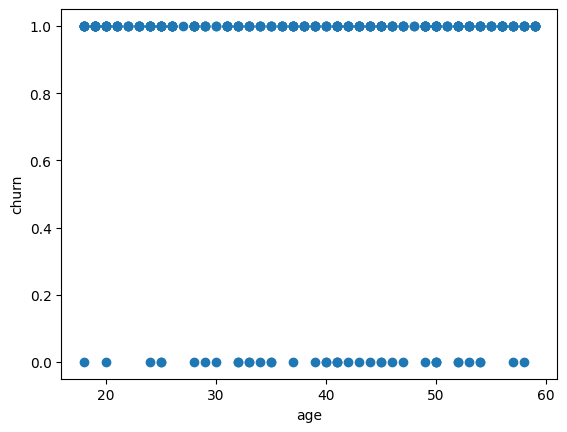

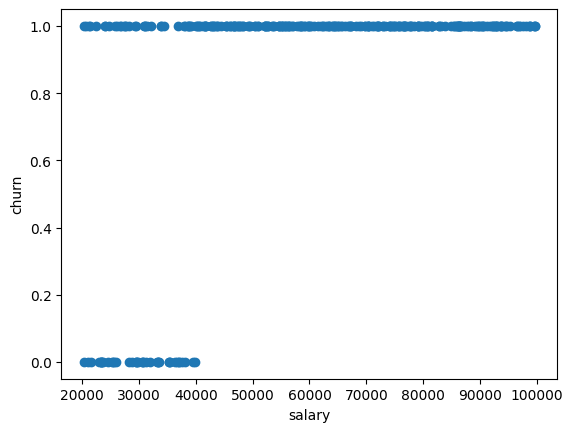

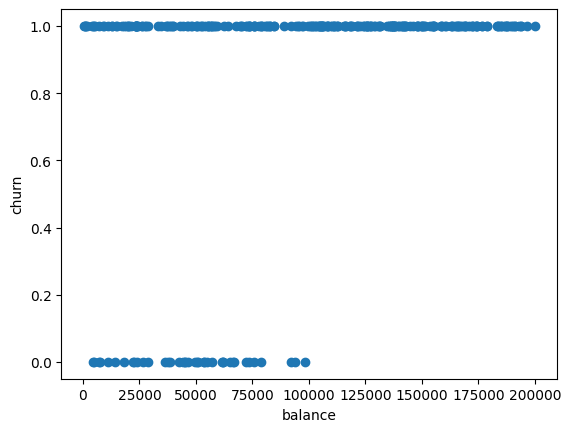

In [9]:
feature = ["age" , "salary" , "balance"]
for col in feature:
    plt.figure()
    plt.scatter(data[col] , data["churn"])
    plt.xlabel(col)
    plt.ylabel("churn")
    plt.show()

In [12]:
x = data[["age" , "salary" , "balance"]]
y = data["churn"]

In [13]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [27]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [29]:
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:,1]

In [30]:
print("accuracy:", accuracy_score(y_test,y_pred))
print("confusion matrix:\n", confusion_matrix(y_test,y_pred))
print("classification report:\n", classification_report(y_test,y_pred))
print("roc_auc:", roc_auc_score(y_test,y_prob))

accuracy: 0.9666666666666667
confusion matrix:
 [[ 6  1]
 [ 1 52]]
classification report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86         7
           1       0.98      0.98      0.98        53

    accuracy                           0.97        60
   macro avg       0.92      0.92      0.92        60
weighted avg       0.97      0.97      0.97        60

roc_auc: 0.9946091644204852


In [31]:
coeff_df = pd.DataFrame({
    "feature":x.columns,
    "coefficient":model.coef_[0]
})
print(coeff_df)

   feature  coefficient
0      age     0.012188
1   salary     0.000320
2  balance     0.000061


In [32]:
new_data = pd.DataFrame({
    "age":[35],
    "salary":[30000],
    "balance":[150000]
})
print("churn prediction:", model.predict(new_data)[0])
print("probability:", model.predict_proba(new_data)[0][1])


churn prediction: 1
probability: 0.9757158550377184
